In [6]:
using Plots, LinearAlgebra, DataFrames
#Vamo a dividir el código en 3 etapas, la primer etapa se tratará de definir las funciones
# Φ que serán la base donde realizaremos la aproximación.
# La segunda etapa consiste en la creación de la matriz de rigidez mediante ensamble
# junto con el vector de las integrales de f con las Φ igullmente en ensamble.
# la tercer etapa se encarga de calcular las normas L2 y H1 para realizar la tabla de convergencia
############################# ETAPA 1 ##################################

#definición de Φ mas. Esta función arroja la recta que pasa por los puntos (a,0) y (b,1).
#nota que está definida para todo x real, no es necesario cortarla porque solo vamos a integrarla
function Φ_mas(x::Float64,a::Float64,b::Float64)
    return (x-a)/(b-a)
end
#definición de Φ menos. Esta función arroja la recta que pasa por los puntos (a,1) y (b,0).
#nota que está definida para todo x real, no es necesario cortarla porque solo vamos a integrarla
function Φ_menos(x::Float64,a::Float64,b::Float64)
    return (x-b)/(a-b)
end
#definición de dΦ más. Esta función es la derivada de Φ_mas. Como son rectas esto es una cte.
function dΦ_mas(x::Float64,a::Float64,b::Float64)
    return 1/(b-a)
end
#definición de dΦ_menos. Esta función es la derivada de Φ_menos. Como son rectas esto es una cte.
function dΦ_menos(x::Float64,a::Float64,b::Float64)
    return 1/(a-b)
end

#esta función Φ es la función hat que tiene como nodo el punto c. ϕ(C)=1 y en a,c es lineal con 
# pendiente positiva, mientras que de c,b es lineal pendiente negativa.
function Φ(x,a,c,b)
    if a <=x && x<=c
        return Φ_mas(x,a,c)
    end
    if c<=x && x<=b
        return Φ_menos(x,c,b)
    end
    return 0.
end
        

###################################### ETAPA 2 #############################################
#Esta es la regla de simpson para calular una integral numércia en el intervalo a y b usando el 
# punto medio a+b/2.
function simpson(f,a::Float64,b::Float64)
    return ((b-a)/6)*(f(a) + 4*f((b+a)/2) + f(b))
end
#Esta es la regla de trapecio para calcular una integral numérica en el intervalo ay b. Solo uso
# los extremos del intervalo, esto es importante más adelante.
function trapecio(f,a,b)
    return (b-a)*(f(b)+f(a))/2
end

#Esta es la matriz de rigidez que se calcula como A_ij=∫ Φ'_i Φ'_j dx en [0,1]. 
# El parámetro N es el número de intervalos (elementos finitos) que tendrá nuestra malla. 
# La forma en que la creamos es haciendo el ensable visto en clase, esta idea consiste en 
# hacer todos los cálculos elemento por elemento (vaya realizas las integrales en cada elemento).
function matriz_rig(N)
    h = 1/N
    M = zeros(N+1,N+1)
    for i ∈ 1:N
        #Definimos las funciones que usaremos para rellenar la diagonal, estas funciones cambian
        #con cada iteración del for. Consiste de un escalon en cada elemento.
        # ϕ'_i * Φ'_i
        dΦ_idΦ_i(x) = dΦ_menos(x,h*(i-1),h*i)*dΦ_menos(x,h*(i-1),h*i)
        # ϕ'_i+1 * Φ'_i+1
        dΦ_i1dΦ_i1(x) = dΦ_mas(x,h*(i-1),h*i)*dΦ_mas(x,h*(i-1),h*i)
        #procedemos a hacer el ensamblado usando trapecio para realizar la integral.
        M[i,i] = M[i,i] + simpson(dΦ_idΦ_i,h*(i-1),h*i)
        M[i+1,i+1] = M[i+1,i+1] + simpson(dΦ_i1dΦ_i1,h*(i-1),h*i)
        #ahora van los elementos cruzados solo estan los consecutivos. Solo aparecen los consecutivos
        # ya que recordemos que las Φ_i valen cero fuera de [x_i-1,x_i] U [x_i,x_i+1].
        # Φ'_i * Φ'_i+1
        dΦ_idΦ_i1(x) = dΦ_menos(x,h*(i-1),h*i)*dΦ_mas(x,h*(i-1),h*i)
        # Φ'_i+1 * Φ'_i
        dΦ_i1dΦ_i(x) = dΦ_mas(x,h*(i-1),h*i)*dΦ_menos(x,h*(i-1),h*i)
        M[i,i+1] = M[i,i+1] + simpson(dΦ_idΦ_i1,h*(i-1),h*i)
        M[i+1,i] = M[i+1,i] + simpson(dΦ_i1dΦ_i,h*(i-1),h*i)
    end
    return M
end

#vamos a general el vector de integrales con f donde cada entrada es F_i = ∫ f Φ_i dx en [0,1].
#De nuevo aplicamos la idea de ensamble.
function vec_sol(f,N)
    h = 1/N
    F = zeros(N+1)
    for i ∈ 1:N
        Φ_menosi_f(x) = Φ_menos(x,h*(i-1),h*i)*f(x)
        Φ_masi1_f(x) = Φ_mas(x,h*(i-1),h*i)*f(x)
        F[i] = F[i] + simpson(Φ_menosi_f,h*(i-1),h*i) 
        F[i+1] = F[i+1] + simpson(Φ_masi1_f,h*(i-1),h*i)
    end
    return F
end
#aquí acoplamos el vector de la parte no lineal
function G(u,N)
    l = zeros(N+1)
    h = 1/N
    for i ∈ 1:N
        Φi_menos_3(x) = (Φ_menos(x,h*(i-1),h*i))^3
        Φi_menos_2_Φi1_mas(x) = ((Φ_menos(x,h*(i-1),h*i))^2)*(Φ_mas(x,h*(i-1),h*i))
        Φi1_mas_2_Φi_menos(x) = ((Φ_mas(x,h*(i-1),h*i))^2)*(Φ_menos(x,h*(i-1),h*i))
        Φi1_mas_3(x) = (Φ_mas(x,h*(i-1),h*i))^3
        
        l[i] = l[i] + (u[i]^2)*simpson(Φi_menos_3,h*(i-1),h*i) +
                2*u[i+1]*u[i]*simpson(Φi_menos_2_Φi1_mas,h*(i-1),h*i) +
                 (u[i+1]^2)*simpson(Φi1_mas_2_Φi_menos,h*(i-1),h*i)
        
        l[i+1] = l[i+1] + (u[i]^2)*simpson(Φi_menos_2_Φi1_mas,h*(i-1),h*i) +
                2*u[i]*u[i+1]*simpson(Φi1_mas_2_Φi_menos,h*(i-1),h*i) +
                (u[i+1]^2)*simpson(Φi1_mas_3,h*(i-1),h*i)
    end
    l[1] = 0.
    l[N+1] = 0.
    return l
end

#acoplamos su matriz jacobiana

function JG(u,N)
    M = zeros(N+1,N+1)
    h=1/N
    for i ∈ 1:N
        Φi_menos_3(x) = (Φ_menos(x,h*(i-1),h*i))^3
        Φi_menos_2_Φi1_mas(x) = ((Φ_menos(x,h*(i-1),h*i))^2)*(Φ_mas(x,h*(i-1),h*i))
        Φi1_mas_2_Φi_menos(x) = ((Φ_mas(x,h*(i-1),h*i))^2)*(Φ_menos(x,h*(i-1),h*i))
        Φi1_mas_3(x) = (Φ_mas(x,h*(i-1),h*i))^3
        
        #rellenamos la diagonal
        M[i,i] = M[i,i] + 2*u[i]*simpson(Φi_menos_3,h*(i-1),h*i) + 
                2*u[i+1]*simpson(Φi_menos_2_Φi1_mas,h*(i-1),h*i)
        M[i+1,i+1] = M[i+1,i+1] + 2*u[i]*simpson(Φi1_mas_2_Φi_menos,h*(i-1),h*i) +
                    2*u[i+1]*simpson(Φi1_mas_3,h*(i-1),h*i)
        
        #ahora las que no son diagonales
        
        M[i,i+1] = M[i,i+1] + 2*u[i]*simpson(Φi_menos_2_Φi1_mas,h*(i-1),h*i) +
                    2*u[i+1]*simpson(Φi1_mas_2_Φi_menos,h*(i-1),h*i)
        
        M[i+1,i] = M[i,i+1]
    end
    M[1,1:N+1] .= 0.
    M[N+1,1:N+1] .= 0.
    return M
end

#se requiere el método de newton

function newton_nD_p2(g,x_o,dg,ϵ,N_max)
    #list_error va a guardar los valores de ||g(x)|| en cada iteración
    list_error = [norm(g(x_o))]
    #list_aprox va a guardar cada una de las aproximaciones para calcular el error en 2 consecutivos
    list_aprox = [x_o]
    i = 1
    x= x_o
    l = []
    while i <= N_max
        #si la derivada vale cero no se puede efectuar la iteración
        if det(dg(x)) == 0. 
            print("la jacobiana no se puede invertir")
        end
        #si no vale cero haz la iteración
        x = x - dg(x) \ g(x)
        #guarda la aproximación de la raiz x
        push!(list_aprox, x)
        #guarda el error
        push!(list_error, norm(g(x)))
        push!(l,norm(dg(x) \ g(x)))
        #checa si la resta de la nueva iteración con la anterior ya cumple la tolerancia
        if norm(list_aprox[i] - x) < ϵ
            print(l)
            return x
        end
        i = i + 1
    end
    print("Excedimos el número maximo de iteraciones")
    #en caso de que excedas el número de iteraciones aún así arroja la aproximación
    return x
end

#esta es la función que resuelve el sistema no lineal y arroja la solución aroximada
function proyecto(f,N)
    H(x) = G(x,N)
    JH(x) = JG(x,N)
    A = matriz_rig(N)
    F = vec_sol(f,N)
    A[1,1] = 1.
    A[1,2:N+1] .= 0.
    A[N+1,1:N] .= 0.
    A[N+1,N+1] = 1.
    F[1] = 0.
    F[N+1] = 0.
    #definimos la funcion que es cero
    W(u) = A*u + H(u) - F
    DW(u) = A + JH(u) 
    ad = ones(N+1)
    u = newton_nD_p2(W,ad,DW,1e-9,100)
    return u
end


############################# Etapa 3 ########################################

# Una vez que tenemos el vector solución u_aprox necesitamos sacar su derivada débil, para esto
# realicé 3 funciones para aproximarla puesto que tenía problemas respecto a la gráfica de 
# la derivada real y la derivada que obtenemos con mis funciones. 
# La función derivada_debil_L y la función derivada_debil_pesos tienen un pequeño desfase
# respecto a la derivada real de la solución. No obstante la tablita de convergencia si sale.
# Por otro lado, la función derivada diferecias si encaja gráficamente con la derivada real y 
# también sale la tabla de convergencia. Explicaré como calculé cada una de las funciones 
# pero al final presentaré la tabla de convergencia con la funcion derivada_diferencias
# que es una derivada numérica.
#Al final mostraré las gráficas usando cada una de las funciones para mostrar el pequeño desfase.

#la función derivada_debil_L toma los nodos X y el vector solución u y arroja la derivada débil.
# Sabemos que la aproximación u = ∑ u_iϕ_i entonces u' = ∑u_iϕ'_i pero recordemos que las 
# ϕ'_i son cero fuera de [x_i-1,x_i] U [x_i,x_i+1] entonces calculo la derivada diciendo que
# el valor u'(x_i) = u(x_i)*(ϕ^-)'_i(x_i) + u(x_i+1)*(ϕ^+)'_i+1(x_i). Esto es tener en cuenta
# solo las contribuciones en el intervalo [x_i,x_i+1].
function derivada_debil_L(X,u)
    k = length(X)
    du = zeros(k)
    for i ∈ 1:k-1
        du[i] = u[i]*dΦ_menos(X[i],X[i],X[i+1]) + u[i+1]*dΦ_mas(X[i],X[i],X[i+1])
    end
    #este vector tiene k-1 elementos porque cuando calcule las normas solo necesito esa cantidad 
    #pues las normas serán recorridas por elemento que juto tenemos k-1=N
    return du
end

#Esta función igual calcula la derivada débil, pero ahora lo que haré es aproximar la derivada
#u'(x_i) teniendo en cuenta las contribuciones en [x_i-1,x_i] U [x_i,x_i+1]. bajo esta idea 
# en los nodos que no sean 0 o 1 pasa
#  u'(x_i) = u(x_i-1)*(ϕ^-)'_i-1(x_i) + u(x_i)*(ϕ^+)'_i(x_i) 
#           + u(x_i)*(ϕ^-)'_i(x_i) + u(x_i+1)*(ϕ^+)'_i+1(x_i)
# no importa donde evalule las (ϕ^-) y (ϕ^+) porque solo son constantes cunado las programé y son el 
# mismo valor para todas. 
function derivada_debil_pesos(X,u)
    k = length(X)
    du = zeros(k)
    du[1] = u[1]*dΦ_menos(X[1],X[1],X[2]) + u[2]*dΦ_mas(X[1],X[1],X[2])
    for i ∈ 1:k-2
        du[i+1] = u[i]*dΦ_menos(X[i],X[i],X[i+1]) + u[i+1]*dΦ_mas(X[i],X[i],X[i+1])
                + u[i+1]*dΦ_menos(X[i+1],X[i+1],X[i+2]) + u[i+2]*dΦ_mas(X[i+1],X[i+1],X[i+2])
    end
    du[k] = u[k-1]*dΦ_menos(X[k-1],X[k-1],X[k]) + u[k]*dΦ_mas(X[k-1],X[k-1],X[k])
    #aquí si tenemos que de tiene N+1 elementos.
    return du
end

#Esta es la típica derivada numérica. que se aproxima por el cociente f'(x) es f'(x_i) - f(x_i+1)/ Δx
function derivada_num(x, u)
    n = length(x)
    du = zeros(n)

    # Derivada hacia adelante para x=0
    du[1] = (u[2] - u[1]) / (x[2] - x[1])

    # Derivada para los puntos interiores f'(x_i) = f(x_i-1) + f(x_i+1)/2Δx
    for i in 2:n-1
        du[i] = (u[i+1] - u[i-1]) / (x[i+1] - x[i-1])
    end

    # Derivada hacia atrás para x=1
    du[n] = (u[n] - u[n-1]) / (x[n] - x[n-1])

    return du
end

# La función trapecio_vec reibe el vector de dos entradas u (la función evaluada u(a) y u(b))
#y el intervalo [a,b] donde será la integración númerica y regresa el valor de la integral.
#Como tendremos la función solo evaluada en los nodos es mejor usar trapecio porque simpson
# requiere el punto intermedio.
function trapecio_vec(u,a::Float64,b::Float64)
    return (b-a)*(u[2]+u[1])/2
end

#La función L2_norm calcula la norma 2 de la función u (en forma de vector) y X son los nodos
#Igual se calcula por ensable
function L2_norm(X,u)
    k = length(X)
    int = 0
    #hacemos el ensamble
    for i ∈ 1:k-1
        int = int + trapecio_vec([(u[i])^2,(u[i+1])^2],X[i],X[i+1])
    end
    return sqrt(int)
end

# la función E_L2 recibe los nodos X, el vector u_an con la sol. análitica en los nodos y 
# el vector u_aprox con la sol. aproximada. 
# regresa el error L2 entre la sol analitica y la aproximada
function E_L2(X,u_an,u_aprox)
    resta = u_an - u_aprox
    return L2_norm(X,resta)
end

# la función E_H1 recibe los nodos X, el vector u_an con la sol. análitica en los nodos,
# el vector du_an con la derivada de la sol. análitica en los nodos y 
# el vector u_aprox con la sol. aproximada. 
# regresa el error H1 entre la sol análitica y la aproximada.
function E_H1(X,u_an,du_an,u_aprox)
    resta = u_an - u_aprox
    #Si se quiere ver como son las tablas con las otras funciones de derivadas solo hay que sustituir
    #en la línea de abajo.
    du_aprox = derivada_debil_pesos(X, u_aprox)
    int= 0
    #hacemos el ensamble, lo hice así porque solo usar la función L2 de nuevo me daba un pequeño error.
    for i ∈ 1:length(X)-1
        err=[(du_an[i]-du_aprox[i])^2,(du_an[i+1]-du_aprox[i])^2]
        int = int + trapecio_vec(err,X[i],X[i+1])
    end
    return sqrt(L2_norm(X,resta)^2 + int)
end


#Esta función genera el interpolador de lagrange. Hace todas las sumas de u = Σ u_i Φ_i
function interpolador(x,u,N)
    vec = [i/N for i ∈ 0:N]
    suma = 0.0
    for k ∈ 1:length(vec)
        suma = suma + u[k]*Φ(x,vec[k]-(1/N),vec[k],vec[k] + 1/N)
    end
    return suma
end

#Esta función calcula la anorma en L2 usando simpson
function norm_L2(f,N)
    int = 0
    f_2(x) = (f(x))^2
    h=1/N
    for k ∈ 1:N
        int = int + simpson(f_2,h*(k-1),k*h)
    end
    return sqrt(int)
end
#esta función calcula el error en la norma 2 entre dos funciones
function error_l2(f,g,N)
    resta(x) = f(x) -g(x)
    return norm_L2(resta,N)
end

#esta función genera la tabla de convergencia
function tabla_proyecto(f,N_vec,u_an,du_an)
    L2_err_norm = []
    H1_err_norm = []
    L2_err_rate = [0.]
    H1_err_rate = [0.]
    for N ∈ N_vec
        u = proyecto(f,N)
        interpolador_function(x) = interpolador(x,u,N)
        X = 0:1/N:1
        u_an_vec = u_an.(X)
        du_an_vec = du_an.(X)
        push!(L2_err_norm,error_l2(interpolador_function,u_an,N))
        push!(H1_err_norm,E_H1(X,u_an_vec,du_an_vec,u))
    end
    
    for k ∈ 1:length(L2_err_norm)-1
        push!(L2_err_rate, (log(L2_err_norm[k+1]/L2_err_norm[k]))/log(1/2))
        push!(H1_err_rate, (log(H1_err_norm[k+1]/H1_err_norm[k]))/log(1/2))
    end
    return DataFrame(N_vec = N_vec,L2_err_norm = L2_err_norm, L2_err_rate= L2_err_rate,
    H1_err_norm = H1_err_norm, H1_err_rate = H1_err_rate)
end

#inicializamos los parametros
f(x) = 4*(π^2)*sin(2*π*x)+ (sin(2*π*x))^2
u_an(x) = sin(2*π*x)
du_an(x) = 2*π*cos(2*π*x)
N_vec = [160]
tabla_proyecto(f,N_vec,u_an,du_an)


Any[1.5139099784828187, 0.0218487139783728, 4.662183428015312e-6, 6.314804293601736e-13, 3.4917565254354893e-13]

,N_vec,L2_err_norm,L2_err_rate,H1_err_norm,H1_err_rate
,Int64,Any,Float64,Any,Float64
1,160,0.000112375,0.0,0.195059,0.0


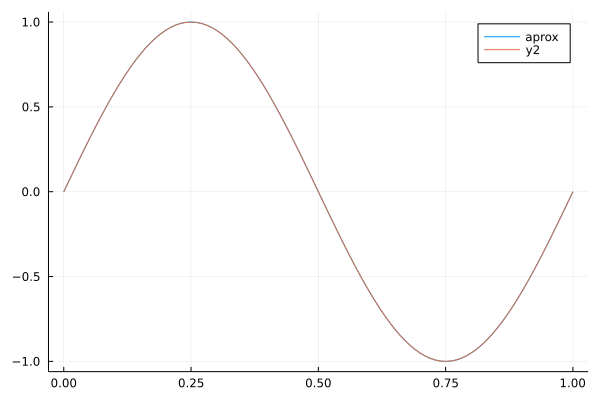

In [2]:
f(x) = 4*(π^2)*sin(2*π*x)+ (sin(2*π*x))^2
u_an(x) = sin(2*π*x)
du_an(x) = 2*π*cos(2*π*x)
u = proyecto(f,100)
interpolador_function(x) = interpolador(x,u,100)

plot(0:1/100:1,interpolador_function.(0:1/100:1),label="aprox")
plot!(0:1/100:1,u_an.(0:1/100:1))